# Active Chemotype Analysis


In [2]:
from pathlib import Path
from rdkit.Chem import rdFingerprintGenerator
import bblean
import bblean.similarity as iSIM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

BASE_DIR = Path('/home/acastanedaleautaud/Documents/Ramon-paper/dataset/Ratio_1/ML/bitbirch-actives/New_approach')
ACTIVES_CSV = BASE_DIR.parent / 'actives_tagged.csv'

BRANCHING_FACTOR = 1024
MERGE_CRITERION = 'diameter'
RECLUSTER_ITERS = 8
N_BITS = 2048
THRESH_Z = 5.5
TSNE_RANDOM_STATE = 42
TOP_N_REPRESENTATIVES = 12

print('Actives CSV:', ACTIVES_CSV)



Actives CSV: /home/acastanedaleautaud/Documents/Ramon-paper/dataset/Ratio_1/ML/bitbirch-actives/actives_tagged.csv


In [3]:
def canonicalize_smiles(val):
    if pd.isna(val):
        return None
    mol = Chem.MolFromSmiles(str(val))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


def draw_cluster_members(cluster_id, active_clusters_df, mols_per_row=4, sub_img_size=(300, 250)):
    cluster_df = (
        active_clusters_df.loc[active_clusters_df["cluster_id"] == cluster_id]
        .sort_values(["Title"])
        .reset_index(drop=True)
    )

    if cluster_df.empty:
        print(f"No molecules found for cluster_id={cluster_id}")
        return None

    mols = [Chem.MolFromSmiles(smi) for smi in cluster_df["SMILES"]]
    legends = [
        f"{row.Title}\ncluster={row.cluster_id}\nsize={row.cluster_size}"
        for row in cluster_df.itertuples(index=False)
    ]

    print(f"cluster_id={cluster_id} | members={len(cluster_df)}")
    return Draw.MolsToGridImage(
        mols,
        molsPerRow=mols_per_row,
        subImgSize=sub_img_size,
        legends=legends,
        useSVG=False,
    )

def prepare_actives_dataframe(path):
    df = pd.read_csv(path)
    if 'Label' in df.columns:
        df = df.loc[pd.to_numeric(df['Label'], errors='coerce') == 1].copy()
    df['SMILES'] = df['SMILES'].map(canonicalize_smiles)
    df = df.dropna(subset=['SMILES']).drop_duplicates(subset='SMILES').reset_index(drop=True)
    return df[['Title', 'SMILES']].copy()


def compute_active_clusters(actives_df):
    fps_packed = bblean.fps_from_smiles(actives_df['SMILES'], pack=True, n_features=N_BITS, kind='ecfp4')
    fps_unpacked = bblean.unpack_fingerprints(fps_packed)

    average_sim = iSIM.jt_isim_unpacked(fps_unpacked)
    representative_samples = iSIM.jt_stratified_sampling(fps_packed, n_samples=min(50, len(actives_df)))
    sim_matrix = iSIM.jt_sim_matrix_packed(fps_packed[representative_samples])
    sim_matrix = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)]
    std = float(np.std(sim_matrix))
    threshold = float(average_sim + THRESH_Z * std)

    bb_tree = bblean.BitBirch(
        branching_factor=BRANCHING_FACTOR,
        threshold=threshold,
        merge_criterion=MERGE_CRITERION,
    )
    bb_tree.fit(fps_packed)
    bb_tree.recluster_inplace(
        iterations=RECLUSTER_ITERS,
        extra_threshold=std,
        shuffle=False,
        verbose=True,
    )
    clusters = bb_tree.get_cluster_mol_ids()

    cluster_id = np.full(len(actives_df), -1, dtype=int)
    cluster_size = np.zeros(len(actives_df), dtype=int)
    for gid, members in enumerate(clusters):
        members = np.asarray(members, dtype=int)
        cluster_id[members] = gid
        cluster_size[members] = len(members)

    out = actives_df.copy()
    out['cluster_id'] = cluster_id
    out['cluster_size'] = cluster_size
    return out, fps_packed, fps_unpacked, clusters, threshold, average_sim, std


def add_tsne_coordinates(fps_unpacked, random_state=42):
    pca_components = min(50, fps_unpacked.shape[0], fps_unpacked.shape[1])
    reduced = PCA(n_components=pca_components, random_state=random_state).fit_transform(fps_unpacked)
    coords = TSNE(
        n_components=2,
        init='pca',
        learning_rate='auto',
        perplexity=min(30, max(5, fps_unpacked.shape[0] - 1)),
        random_state=random_state,
    ).fit_transform(reduced)
    return coords



def pick_cluster_medoid(cluster_members, rdkit_fps):
    members = np.asarray(cluster_members, dtype=int)
    if members.size == 1:
        return int(members[0])

    mean_sims = []
    member_fps = [rdkit_fps[i] for i in members]

    for i, fp in enumerate(member_fps):
        sims = DataStructs.BulkTanimotoSimilarity(fp, member_fps)
        mean_sims.append(float(np.mean(sims)))

    return int(members[int(np.argmax(mean_sims))])


actives_df = prepare_actives_dataframe(ACTIVES_CSV)
active_clusters_df, fps_packed, fps_unpacked, clusters, threshold, average_sim, std = compute_active_clusters(actives_df)
coords = add_tsne_coordinates(fps_unpacked, random_state=TSNE_RANDOM_STATE)
active_clusters_df['tsne_1'] = coords[:, 0]
active_clusters_df['tsne_2'] = coords[:, 1]

print(f'Actives: {len(active_clusters_df)}')
print(f'Active clusters: {len(clusters)}')
print(f'Singleton active clusters: {sum(len(c) == 1 for c in clusters)}')
print(f'BitBirch threshold: {threshold:.4f} (mean={average_sim:.4f}, std={std:.4f})')

Current number of clusters: 651
Current number of singletons: 410
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Current number of clusters: 637
Current number of singletons: 400
Final number of clusters: 637
Final number of singletons: 400
Actives: 1690
Active clusters: 637
Singleton active clusters: 400
BitBirch threshold: 0.4106 (mean=0.1088, std=0.0549)


In [4]:
cluster_size_summary = (
    active_clusters_df[['cluster_id', 'cluster_size']]
    .drop_duplicates()
    .sort_values('cluster_size', ascending=False)
    .reset_index(drop=True)
)

singleton_count = int((cluster_size_summary['cluster_size'] == 1).sum())
print('Number of singleton active clusters:', singleton_count)
display(cluster_size_summary.head(15))


Number of singleton active clusters: 400


,cluster_id,cluster_size
0,0,105
1,1,32
2,2,30
3,3,28
4,4,24
5,5,23
6,6,23
7,7,22
8,9,21
9,8,21


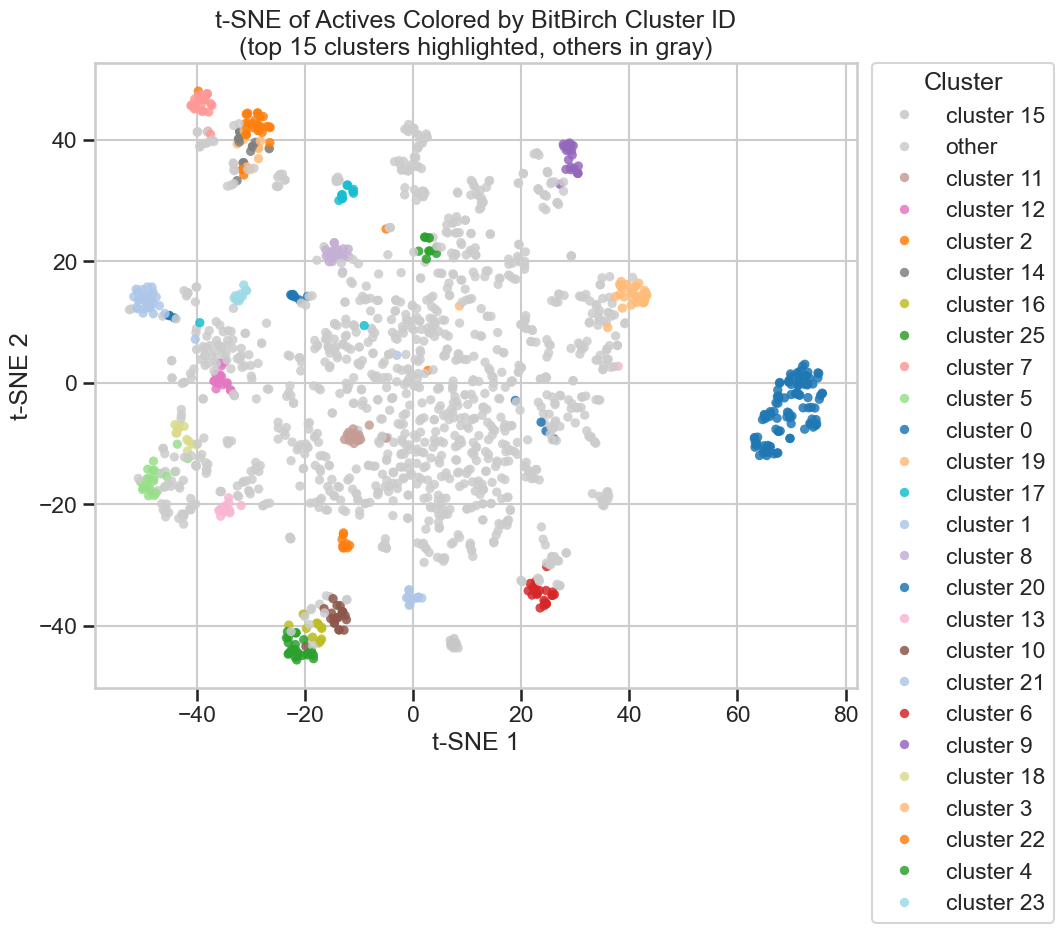

In [186]:
cluster_order = cluster_size_summary['cluster_id'].tolist()
top_clusters = cluster_order[:25]

plot_df = active_clusters_df.copy()
plot_df['cluster_group'] = plot_df['cluster_id'].where(plot_df['cluster_id'].isin(top_clusters), other=-1)
plot_df['cluster_group_label'] = plot_df['cluster_group'].map(lambda x: 'other' if x == -1 else f'cluster {x}')

palette = sns.color_palette('tab20', n_colors=len(top_clusters))
palette_map = {f'cluster {cid}': palette[i % len(palette)] for i, cid in enumerate(top_clusters)}
palette_map['other'] = (0.8, 0.8, 0.8)

fig, ax = plt.subplots(figsize=(11, 9))
sns.scatterplot(
    data=plot_df,
    x='tsne_1',
    y='tsne_2',
    hue='cluster_group_label',
    palette=palette_map,
    s=45,
    linewidth=0,
    alpha=0.85,
    ax=ax,
)
ax.set_title('t-SNE of Actives Colored by BitBirch Cluster ID\n(top 15 clusters highlighted, others in gray)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.0, frameon=True, title='Cluster')
plt.tight_layout()
plt.show()

,cluster_id,cluster_size,Title,SMILES,medoid_idx
0,0,105,SR-01000096664,COc1ccc(N2CSC3=C(C#N)C(c4ccccc4)CC(=O)N3C2)cc1,138
1,1,32,SR-01000359123,O=C(Cc1ccccc1)OCC(=O)c1ccc([N+](=O)[O-])cc1,979
2,2,30,SR-01000474787,O=C(Oc1ccc2oc(=O)sc2c1)c1ccccc1,45
3,3,28,SR-01000584449,COc1ccc(NC(=O)c2c(NCc3cccnc3)sc3c2CCCC3)cc1,758
4,4,24,SR-01000242852,CC(=O)OC(OC(C)=O)C12C=CC(O1)C1C(=O)N(c3ccccc3-...,931
5,5,23,SR-01000221872,COc1ccc(C=C2C(=O)NC(=S)NC2=O)cc1OCc1ccccc1,759
6,6,23,SR-01000208024,CCCCC1(C)NC(=S)N(c2ccccc2)N1,864
7,7,22,SR-01000104448,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1ccccc1,127
8,9,21,SR-01000444942,Cc1ccc(-c2csc(NC(=O)c3cc(-c4cccs4)nc4ccccc34)n...,346
9,8,21,SR-01000227904,Cc1ccc(NC(=O)/C=C/c2ccc(C)o2)cc1,1160


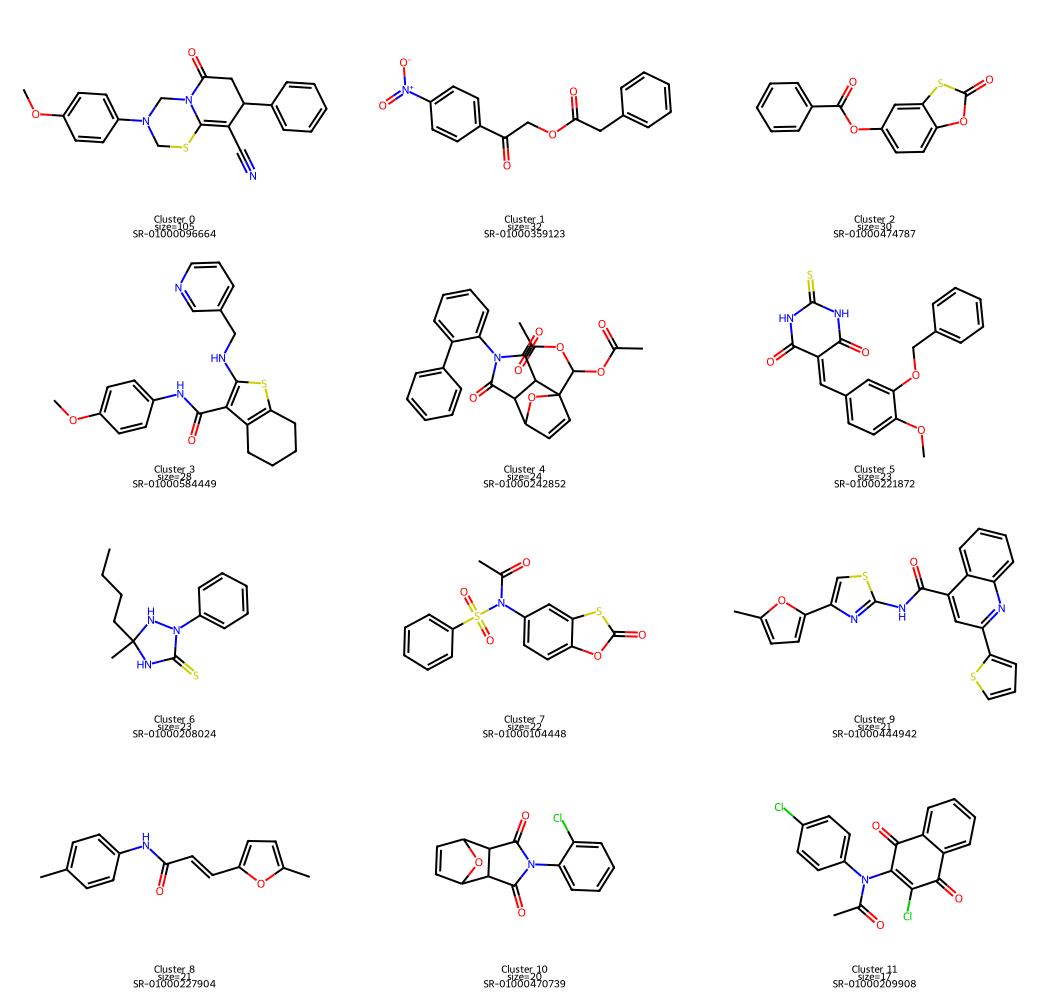

In [5]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

rdkit_fps = [
    morgan_generator.GetFingerprint(Chem.MolFromSmiles(smi))
    for smi in active_clusters_df["SMILES"]
]

representative_rows = []
top_cluster_ids = cluster_size_summary.head(TOP_N_REPRESENTATIVES)['cluster_id'].tolist()

for cid in top_cluster_ids:
    members = clusters[cid]
    medoid_idx = pick_cluster_medoid(members, rdkit_fps)
    row = active_clusters_df.iloc[medoid_idx]
    representative_rows.append(
        {
            'cluster_id': int(cid),
            'cluster_size': int(len(members)),
            'Title': row['Title'],
            'SMILES': row['SMILES'],
            'medoid_idx': int(medoid_idx),
        }
    )

representatives_df = pd.DataFrame(representative_rows)
display(representatives_df)

rep_mols = [Chem.MolFromSmiles(smi) for smi in representatives_df['SMILES']]
rep_legends = [
    f"Cluster {row.cluster_id}\nsize={row.cluster_size}\n{row.Title}"
    for row in representatives_df.itertuples(index=False)
]

img = Draw.MolsToGridImage(
    rep_mols,
    molsPerRow=3,
    subImgSize=(350, 250),
    legends=rep_legends,
    useSVG=False,
)
img

cluster_id=3 | members=28


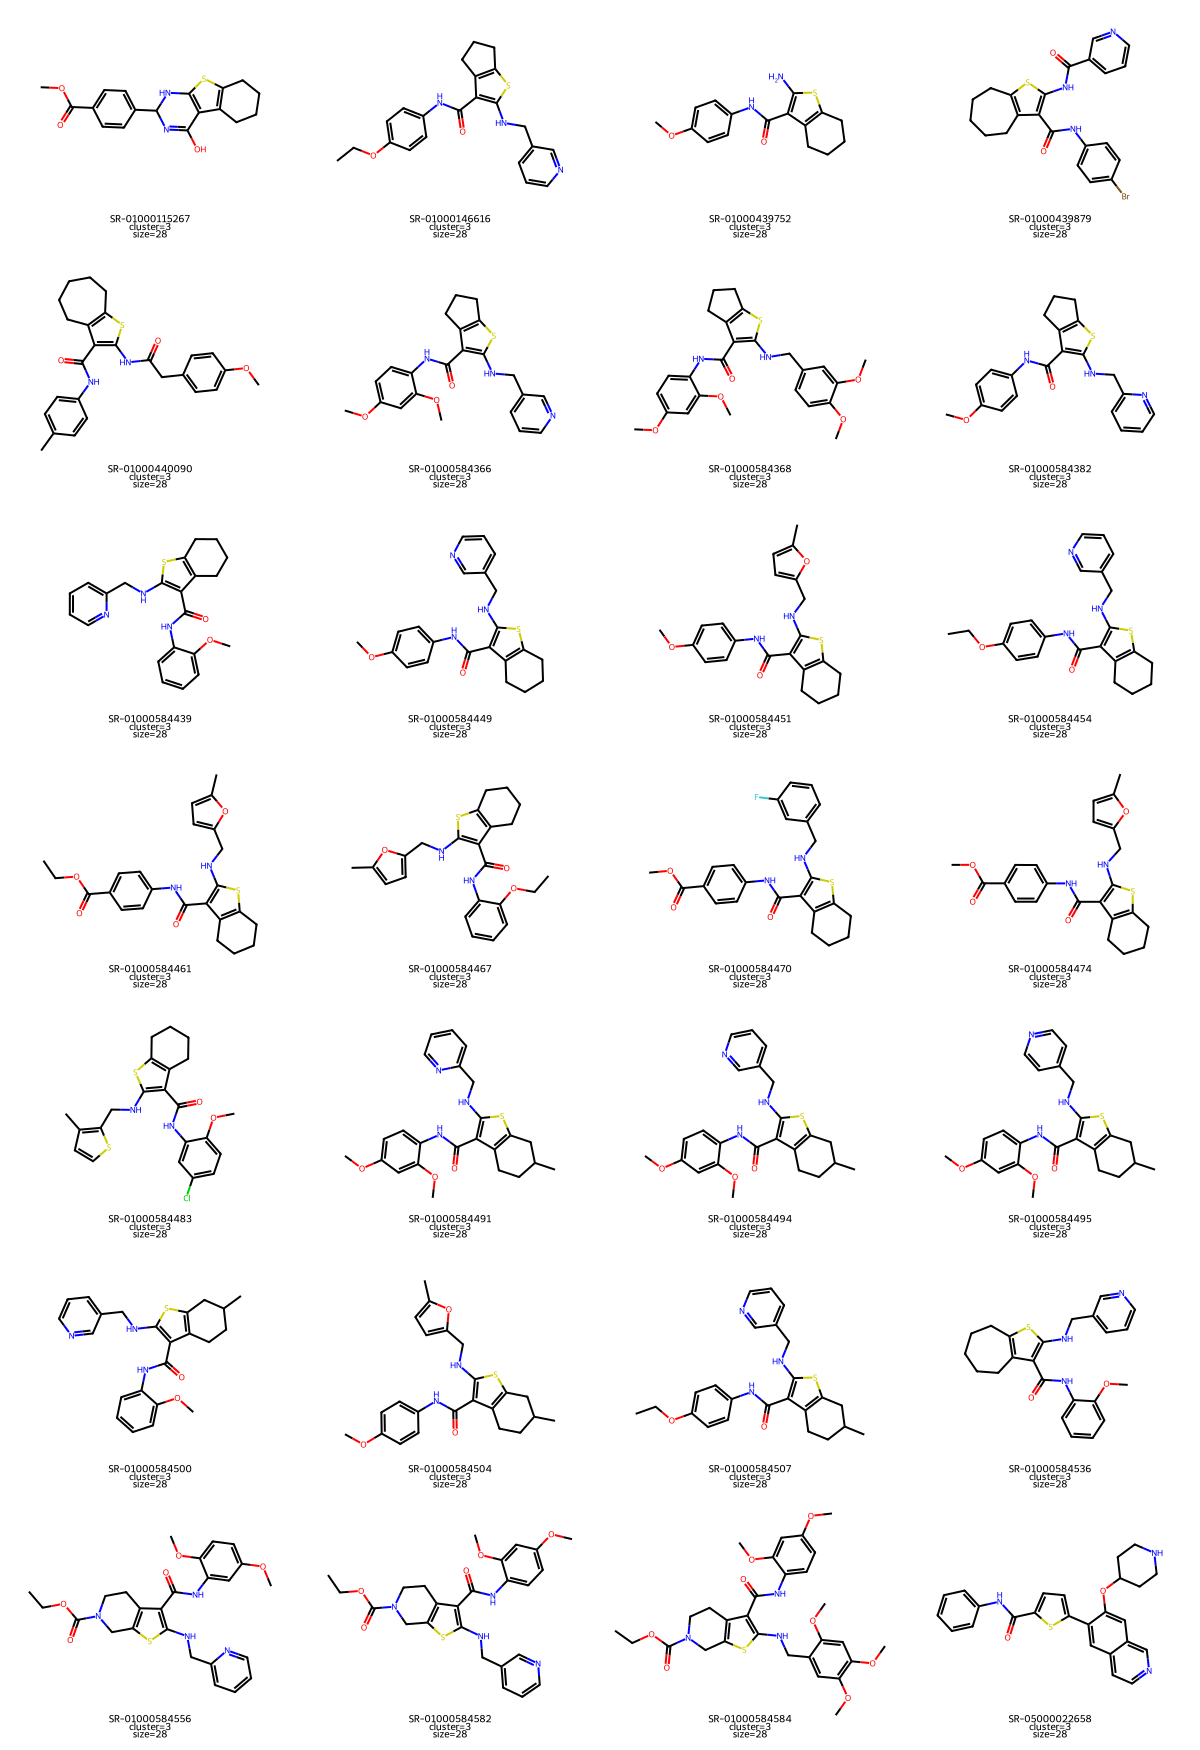

In [6]:
draw_cluster_members(3, active_clusters_df)


In [7]:


def cluster_jaccard_summary(active_clusters_df, rdkit_fps):
    rows = []

    for cluster_id, sub_df in active_clusters_df.groupby("cluster_id"):
        member_idx = sub_df.index.to_numpy()
        fps = [rdkit_fps[i] for i in member_idx]
        n = len(fps)

        if n == 1:
            sims = [1.0]
        else:
            sims = []
            for i in range(n):
                pair_sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
                sims.extend(pair_sims)

        sims = np.asarray(sims, dtype=float)

        rows.append({
            "cluster_id": int(cluster_id),
            "cluster_size": int(n),
            "mean_jaccard": float(np.mean(sims)),
            "median_jaccard": float(np.median(sims)),
            "min_jaccard": float(np.min(sims)),
            "max_jaccard": float(np.max(sims)),
        })

    summary = pd.DataFrame(rows).sort_values(
        ["mean_jaccard", "cluster_size"], ascending=[False, False]
    ).reset_index(drop=True)

    return summary
cluster_jaccard_df = cluster_jaccard_summary(active_clusters_df, rdkit_fps)
cluster_jaccard_df = cluster_jaccard_df.sort_values(
    "cluster_size", ascending=False
).reset_index(drop=True)

display(cluster_jaccard_df.head(20))


,cluster_id,cluster_size,mean_jaccard,median_jaccard,min_jaccard,max_jaccard
0,0,105,0.493858,0.480519,0.161290,0.924528
1,1,32,0.444487,0.443534,0.135135,0.911111
2,2,30,0.448314,0.444444,0.140625,0.826087
3,3,28,0.451441,0.434211,0.148515,0.965517
4,4,24,0.479799,0.434783,0.289474,0.816667
5,5,23,0.417220,0.409091,0.257576,0.735849
6,6,23,0.478458,0.458333,0.207547,0.921053
7,7,22,0.490477,0.468750,0.204819,0.836735
8,8,21,0.467304,0.467437,0.253731,1.000000
9,9,21,0.435305,0.393129,0.230769,0.980769


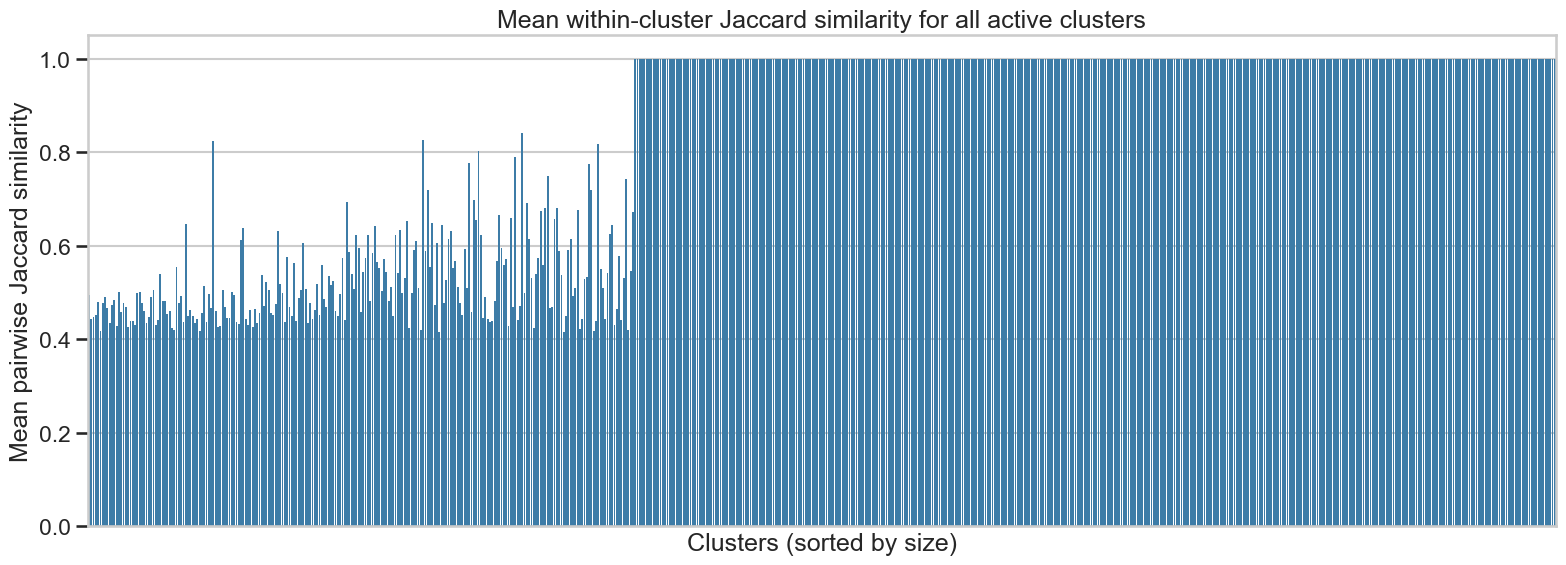

In [8]:
plot_df = cluster_jaccard_df.sort_values("cluster_size", ascending=False).copy()

plt.figure(figsize=(16, 6))
sns.barplot(
    data=plot_df,
    x="cluster_id",
    y="mean_jaccard",
    color="#2c7fb8"
)
plt.xticks([], [])
plt.xlabel("Clusters (sorted by size)")
plt.ylabel("Mean pairwise Jaccard similarity")
plt.title("Mean within-cluster Jaccard similarity for all active clusters")
plt.tight_layout()
plt.show()


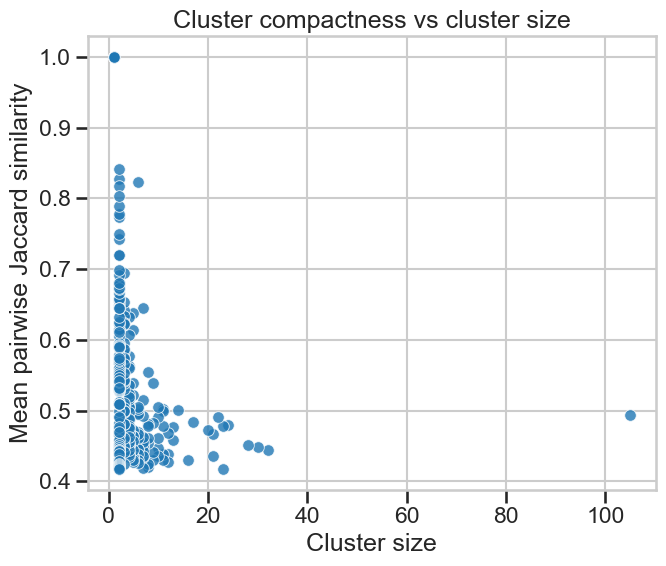

In [9]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=cluster_jaccard_df,
    x="cluster_size",
    y="mean_jaccard",
    s=70,
    alpha=0.8
)
plt.xlabel("Cluster size")
plt.ylabel("Mean pairwise Jaccard similarity")
plt.title("Cluster compactness vs cluster size")
plt.tight_layout()
plt.show()


In [10]:

singleton_df = active_clusters_df.loc[active_clusters_df["cluster_size"] == 1].copy()
print("Singleton actives:", len(singleton_df))


Singleton actives: 400


In [11]:
def singleton_neighbor_analysis(singleton_df, active_clusters_df, rdkit_fps):
    rows = []
    all_idx = active_clusters_df.index.to_numpy()

    for row in singleton_df.itertuples():
        idx = row.Index
        fp = rdkit_fps[idx]

        other_idx = all_idx[all_idx != idx]
        other_fps = [rdkit_fps[i] for i in other_idx]
        sims = np.asarray(DataStructs.BulkTanimotoSimilarity(fp, other_fps), dtype=float)

        best_pos = int(np.argmax(sims))
        best_idx = int(other_idx[best_pos])
        best_row = active_clusters_df.iloc[best_idx]

        rows.append({
            "singleton_cluster_id": int(row.cluster_id),
            "Title": row.Title,
            "nearest_active_title": best_row["Title"],
            "nearest_active_cluster_id": int(best_row["cluster_id"]),
            "nearest_active_cluster_size": int(best_row["cluster_size"]),
            "max_similarity_to_any_active": float(np.max(sims)),
            "n_sim_ge_0_5": int(np.sum(sims >= 0.5)),
            "n_sim_ge_0_6": int(np.sum(sims >= 0.6)),
            "n_sim_ge_0_7": int(np.sum(sims >= 0.7)),
        })

    return pd.DataFrame(rows).sort_values(
        "max_similarity_to_any_active", ascending=False
    ).reset_index(drop=True)
singleton_neighbor_analysis(singleton_df, active_clusters_df, rdkit_fps)

,singleton_cluster_id,Title,nearest_active_title,nearest_active_cluster_id,nearest_active_cluster_size,max_similarity_to_any_active,n_sim_ge_0_5,n_sim_ge_0_6,n_sim_ge_0_7
0,565,SR-01000441970,SR-01000014310,8,21,0.734694,1,1,1
1,601,SR-01000198941,SR-01000421325,16,12,0.608696,3,2,0
2,483,SR-01000575475,SR-01000576402,73,5,0.604167,2,1,0
3,522,SR-01000390175,SR-01000509565,19,11,0.575000,1,0,0
4,624,SR-01000314636,SR-01000242145,132,3,0.549020,1,0,0
...,...,...,...,...,...,...,...,...,...
395,370,SR-01000083286,SR-01000530144,12,16,0.169811,0,0,0
396,447,SR-01000319795,SR-01000584382,3,28,0.164384,0,0,0
397,310,SR-05000002039,SR-01000086696,145,2,0.160714,0,0,0
398,433,SR-05000002141,SR-01000089866,172,2,0.140000,0,0,0


In [12]:
singleton_neighbor_df = singleton_neighbor_analysis(
    singleton_df, active_clusters_df, rdkit_fps
)

singleton_neighbor_df["singleton_type"] = pd.cut(
    singleton_neighbor_df["max_similarity_to_any_active"],
    bins=[-np.inf, 0.5, 0.7, np.inf],
    labels=["likely_isolated", "ambiguous", "likely_boundary"]
)

singleton_neighbor_df["singleton_type"].value_counts()


singleton_type
likely_isolated    394
ambiguous            5
likely_boundary      1
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

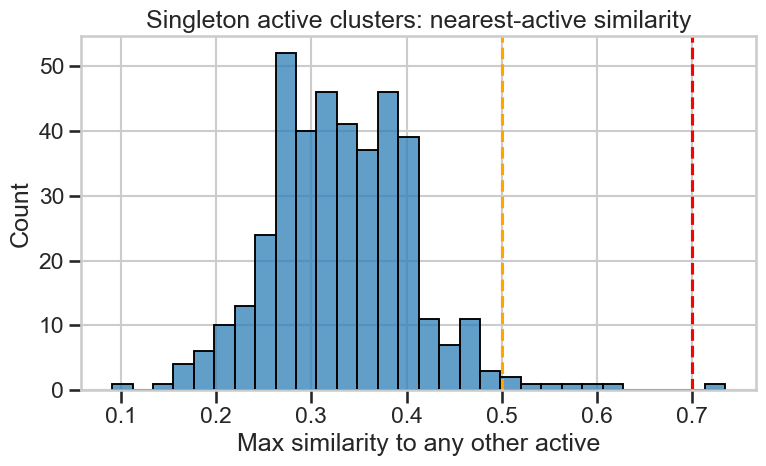

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(
    singleton_neighbor_df["max_similarity_to_any_active"],
    bins=30,
    color="#2c7fb8",
    edgecolor="black"
)
plt.axvline(0.5, color="orange", linestyle="--")
plt.axvline(0.7, color="red", linestyle="--")
plt.xlabel("Max similarity to any other active")
plt.ylabel("Count")
plt.title("Singleton active clusters: nearest-active similarity")
plt.tight_layout()
plt.savefig("singleton_active_clusters.png", dpi=800)
plt.show